# 04 · Weather Data

**Input :** `data/processed/panel_daily.parquet` (station coordinates)  
**Outputs:** `data/processed/weather_hourly.parquet` · `data/processed/weather_daily.parquet`

Steps:
0. Imports & setup
1. Load AWV station coordinates
2. Set up Open-Meteo API client
3. Define weather variables
4. Fetch hourly weather for all stations (cached)
5. Add derived weather variables
6. Save hourly weather panel
7. Build daily weather aggregates
8. Sanity check plots
9. Final summary

## 0. Imports & Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "openmeteo-requests", "requests-cache", "retry-requests"])

from pathlib import Path
import time

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import openmeteo_requests
import pandas as pd
import requests_cache
from retry_requests import retry

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
RAW_WX    = ROOT / "data" / "raw" / "weather"
FIGS      = ROOT / "outputs" / "figures"
RAW_WX.mkdir(parents=True, exist_ok=True)

SEASON_MAP = {
    12: "winter",  1: "winter",  2: "winter",
     3: "spring",  4: "spring",  5: "spring",
     6: "summer",  7: "summer",  8: "summer",
     9: "autumn", 10: "autumn", 11: "autumn",
}

URL        = "https://archive-api.open-meteo.com/v1/archive"
START_DATE = "2024-01-01"
END_DATE   = "2025-12-31"

## 1. Load AWV Station Coordinates

In [2]:
panel_daily = pd.read_parquet(
    PROCESSED / "panel_daily.parquet",
    columns=["site ID", "naam", "lat", "lon"],
)

site_locations = (
    panel_daily[["site ID", "naam", "lat", "lon"]]
    .drop_duplicates("site ID")
    .dropna(subset=["lat", "lon"])
    .reset_index(drop=True)
)

print(f"Unique stations        : {len(site_locations)}")
print(f"Lat range              : {site_locations['lat'].min():.4f} – {site_locations['lat'].max():.4f}")
print(f"Lon range              : {site_locations['lon'].min():.4f} – {site_locations['lon'].max():.4f}")
site_locations.head(5)

Unique stations        : 149
Lat range              : 50.7513 – 51.3575
Lon range              : 2.7429 – 5.7973


,site ID,naam,lat,lon
0,1,Machelen,50.916183,4.456122
1,2,Brasschaat 2,51.275120,4.471690
2,3,Brasschaat 1,51.275030,4.472220
3,4,Balen 1,51.160230,5.190110
4,5,Balen 2,51.160180,5.190030


## 2. Set Up Open-Meteo API Client

In [3]:
cache_session = requests_cache.CachedSession(
    str(RAW_WX / ".cache"), expire_after=-1   # never expire
)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

print("API client ready (disk cache + auto-retry).")

API client ready (disk cache + auto-retry).


## 3. Define Weather Variables

In [4]:
VARIABLES = [
    "temperature_2m",        # °C
    "precipitation",         # mm / hour
    "wind_speed_10m",        # km/h
    "relative_humidity_2m",  # %
    "sunshine_duration",     # seconds per hour
    "wind_gusts_10m",        # km/h  (extreme weather flagging)
    "rain",                  # mm (rain only, no snow)
    "snowfall",              # cm
    "weather_code",          # WMO code
]

print(f"Variables : {VARIABLES}")
print(f"Period    : {START_DATE} → {END_DATE}")
print(f"Stations  : {len(site_locations)}")

Variables : ['temperature_2m', 'precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'sunshine_duration', 'wind_gusts_10m', 'rain', 'snowfall', 'weather_code']
Period    : 2024-01-01 → 2025-12-31
Stations  : 149


## 4. Fetch Weather Data for All Stations

Each station is fetched individually from the Open-Meteo archive API.  
The `requests_cache` layer writes responses to disk so re-runs are instant.

In [5]:
from openmeteo_requests import OpenMeteoRequestsError

CHECKPOINT = RAW_WX / "weather_checkpoint.parquet"

# Resume from checkpoint if it exists
if CHECKPOINT.exists():
    done = pd.read_parquet(CHECKPOINT)
    fetched_ids = set(done["site ID"].unique())
    all_weather = [done]
    print(f"Resuming: {len(fetched_ids)} stations already fetched.")
else:
    fetched_ids = set()
    all_weather = []

remaining = site_locations[~site_locations["site ID"].isin(fetched_ids)]
print(f"Stations to fetch: {len(remaining)}")

for _, row in remaining.iterrows():
    params = {
        "latitude":   row["lat"],
        "longitude":  row["lon"],
        "start_date": START_DATE,
        "end_date":   END_DATE,
        "hourly":     VARIABLES,
        "timezone":   "Europe/Brussels",
    }

    for attempt in range(10):
        try:
            response = openmeteo.weather_api(URL, params=params)[0]
            break
        except OpenMeteoRequestsError as e:
            if "limit exceeded" in str(e).lower():
                print(f"  Rate limited, waiting 90s (attempt {attempt+1}/10)...")
                time.sleep(90)
            else:
                raise
    else:
        raise RuntimeError(f"Failed after 10 attempts for site {row['site ID']}")

    hourly = response.Hourly()

    t_start = (
        pd.to_datetime(hourly.Time(), unit="s", utc=True)
        .tz_convert("Europe/Brussels")
        .replace(tzinfo=None)
    )
    t_end = (
        pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True)
        .tz_convert("Europe/Brussels")
        .replace(tzinfo=None)
    )
    freq = pd.Timedelta(seconds=hourly.Interval())

    df = pd.DataFrame({
        "site ID":              row["site ID"],
        "datetime":             pd.date_range(start=t_start, end=t_end,
                                              freq=freq, inclusive="left"),
        "temperature_2m":       hourly.Variables(0).ValuesAsNumpy(),
        "precipitation":        hourly.Variables(1).ValuesAsNumpy(),
        "wind_speed_10m":       hourly.Variables(2).ValuesAsNumpy(),
        "relative_humidity_2m": hourly.Variables(3).ValuesAsNumpy(),
        "sunshine_duration":    hourly.Variables(4).ValuesAsNumpy(),
        "wind_gusts_10m":       hourly.Variables(5).ValuesAsNumpy(),
        "rain":                 hourly.Variables(6).ValuesAsNumpy(),
        "snowfall":             hourly.Variables(7).ValuesAsNumpy(),
        "weather_code":         hourly.Variables(8).ValuesAsNumpy(),
    })

    all_weather.append(df)

    # Save checkpoint every 10 stations
    n_total = len(fetched_ids) + len([x for x in all_weather if x["site ID"].iloc[0] not in fetched_ids])
    if len(all_weather) % 10 == 0:
        pd.concat(all_weather, ignore_index=True).to_parquet(CHECKPOINT, index=False)
        print(f"  Checkpoint saved at {len(all_weather)} new stations")

    n = len(fetched_ids) + len(all_weather)
    if n % 10 == 0 or n == len(site_locations):
        print(f"  Fetched {n}/{len(site_locations)} stations")

    time.sleep(8)

weather_raw = pd.concat(all_weather, ignore_index=True)

# Clean up checkpoint after successful completion
if CHECKPOINT.exists():
    CHECKPOINT.unlink()

print(f"\nRaw weather data shape: {weather_raw.shape}")
weather_raw.head(3)

Stations to fetch: 149
  Checkpoint saved at 10 new stations
  Fetched 10/149 stations
  Checkpoint saved at 20 new stations
  Fetched 20/149 stations
  Checkpoint saved at 30 new stations
  Fetched 30/149 stations
  Checkpoint saved at 40 new stations
  Fetched 40/149 stations
  Checkpoint saved at 50 new stations
  Fetched 50/149 stations
  Checkpoint saved at 60 new stations
  Fetched 60/149 stations
  Checkpoint saved at 70 new stations
  Fetched 70/149 stations
  Checkpoint saved at 80 new stations
  Fetched 80/149 stations
  Checkpoint saved at 90 new stations
  Fetched 90/149 stations
  Checkpoint saved at 100 new stations
  Fetched 100/149 stations
  Checkpoint saved at 110 new stations
  Fetched 110/149 stations
  Checkpoint saved at 120 new stations
  Fetched 120/149 stations
  Checkpoint saved at 130 new stations
  Fetched 130/149 stations
  Checkpoint saved at 140 new stations
  Fetched 140/149 stations
  Fetched 149/149 stations

Raw weather data shape: (2614056, 11)


,site ID,datetime,temperature_2m,precipitation,wind_speed_10m,relative_humidity_2m,sunshine_duration,wind_gusts_10m,rain,snowfall,weather_code
0,1,2023-12-31 23:00:00,7.85,0.0,36.376038,72.439613,0.0,64.799995,0.0,0.0,3.0
1,1,2024-01-01 00:00:00,8.25,0.0,36.044971,70.000916,0.0,65.159996,0.0,0.0,3.0
2,1,2024-01-01 01:00:00,7.95,0.0,35.457714,70.938263,0.0,64.799995,0.0,0.0,3.0


## 5. Add Derived Weather Variables

In [6]:
weather_raw["is_raining"] = weather_raw["precipitation"] > 0.1

weather_raw["rain_category"] = pd.cut(
    weather_raw["precipitation"],
    bins=[-0.01, 0.1, 1.0, 3.0, float("inf")],
    labels=["none", "light", "moderate", "heavy"],
)

weather_raw["temp_category"] = pd.cut(
    weather_raw["temperature_2m"],
    bins=[-float("inf"), 0, 5, 10, 15, 20, 25, float("inf")],
    labels=["freezing", "very_cold", "cold", "cool", "mild", "warm", "hot"],
)

weather_raw["wind_category"] = pd.cut(
    weather_raw["wind_speed_10m"],
    bins=[-0.01, 10, 20, 30, float("inf")],
    labels=["calm", "light", "moderate", "strong"],
)

weather_raw["sunshine_min"]    = weather_raw["sunshine_duration"] / 60
weather_raw["hour"]            = weather_raw["datetime"].dt.hour
weather_raw["is_peak_morning"] = weather_raw["hour"].isin([7, 8])
weather_raw["is_peak_evening"] = weather_raw["hour"].isin([17, 18])

# midnight timestamp (datetime64[ns]) — matches panel_daily["date"] dtype
weather_raw["date"] = weather_raw["datetime"].dt.normalize()

print("Derived columns added. Sample dtypes:")
print(weather_raw[["rain_category", "temp_category", "wind_category",
                    "sunshine_min", "is_peak_morning", "date"]].dtypes)

Derived columns added. Sample dtypes:
rain_category            category
temp_category            category
wind_category            category
sunshine_min              float32
is_peak_morning              bool
date               datetime64[ns]
dtype: object


## 6. Save Hourly Weather Panel

In [7]:
out_h = PROCESSED / "weather_hourly.parquet"
weather_raw.to_parquet(out_h, index=False)
size_h = out_h.stat().st_size / 1_048_576

print(f"Saved : {out_h.name}")
print(f"Shape : {weather_raw.shape}")
print(f"Size  : {size_h:.1f} MB")
print(f"\nNaN count per column:")
print(weather_raw.isna().sum())

Saved : weather_hourly.parquet
Shape : (2614056, 20)
Size  : 29.3 MB

NaN count per column:
site ID                 0
datetime                0
temperature_2m          0
precipitation           0
wind_speed_10m          0
relative_humidity_2m    0
sunshine_duration       0
wind_gusts_10m          0
rain                    0
snowfall                0
weather_code            0
is_raining              0
rain_category           0
temp_category           0
wind_category           0
sunshine_min            0
hour                    0
is_peak_morning         0
is_peak_evening         0
date                    0
dtype: int64


## 7. Build Daily Weather Aggregates

Commute-period columns (`precip_morning/evening`, `wind_morning/evening`) are
computed via separate filtered groupbys rather than `agg` lambdas — much faster
on ~2.6M rows.

In [8]:
# ── base daily aggregation ────────────────────────────────────────────────────
daily_weather = (
    weather_raw.groupby(["site ID", "date"], as_index=False).agg(
        temp_avg    =("temperature_2m",       "mean"),
        temp_max    =("temperature_2m",       "max"),
        temp_min    =("temperature_2m",       "min"),
        precip_total=("precipitation",        "sum"),
        wind_avg    =("wind_speed_10m",       "mean"),
        wind_max    =("wind_gusts_10m",       "max"),
        humidity_avg=("relative_humidity_2m", "mean"),
        sunshine_min=("sunshine_min",         "sum"),
        rain_hours  =("is_raining",           "sum"),
    )
)

# ── commute-period aggregates ─────────────────────────────────────────────────
morn = (
    weather_raw[weather_raw["is_peak_morning"]]
    .groupby(["site ID", "date"], as_index=False)
    .agg(precip_morning=("precipitation",  "sum"),
         wind_morning  =("wind_speed_10m", "mean"))
)
eve = (
    weather_raw[weather_raw["is_peak_evening"]]
    .groupby(["site ID", "date"], as_index=False)
    .agg(precip_evening=("precipitation",  "sum"),
         wind_evening  =("wind_speed_10m", "mean"))
)

daily_weather = (
    daily_weather
    .merge(morn, on=["site ID", "date"], how="left")
    .merge(eve,  on=["site ID", "date"], how="left")
)

# ── bad weather flags ─────────────────────────────────────────────────────────
daily_weather["is_rainy_day"]   = daily_weather["precip_total"] > 1.0
daily_weather["is_cold_day"]    = daily_weather["temp_avg"]     < 5.0
daily_weather["is_windy_day"]   = daily_weather["wind_avg"]     > 30.0
daily_weather["is_bad_weather"] = (
    daily_weather["is_rainy_day"] |
    daily_weather["is_cold_day"]  |
    daily_weather["is_windy_day"]
)

out_d = PROCESSED / "weather_daily.parquet"
daily_weather.to_parquet(out_d, index=False)
size_d = out_d.stat().st_size / 1_048_576

print(f"Saved : {out_d.name}")
print(f"Shape : {daily_weather.shape}")
print(f"Size  : {size_d:.1f} MB")
print(f"\nSample (3 rows):")
display(daily_weather[["site ID", "date", "temp_avg", "precip_total",
                        "wind_avg", "sunshine_min", "is_bad_weather"]].head(3))

Saved : weather_daily.parquet
Shape : (109068, 19)
Size  : 2.6 MB

Sample (3 rows):


,site ID,date,temp_avg,precip_total,wind_avg,sunshine_min,is_bad_weather
0,1,2023-12-31,7.850000,0.0,36.376038,0.000000,True
1,1,2024-01-01,7.302083,2.3,28.195847,360.267792,True
2,1,2024-01-02,10.522917,21.6,33.943661,0.000000,True


## 8. Sanity Check Plots

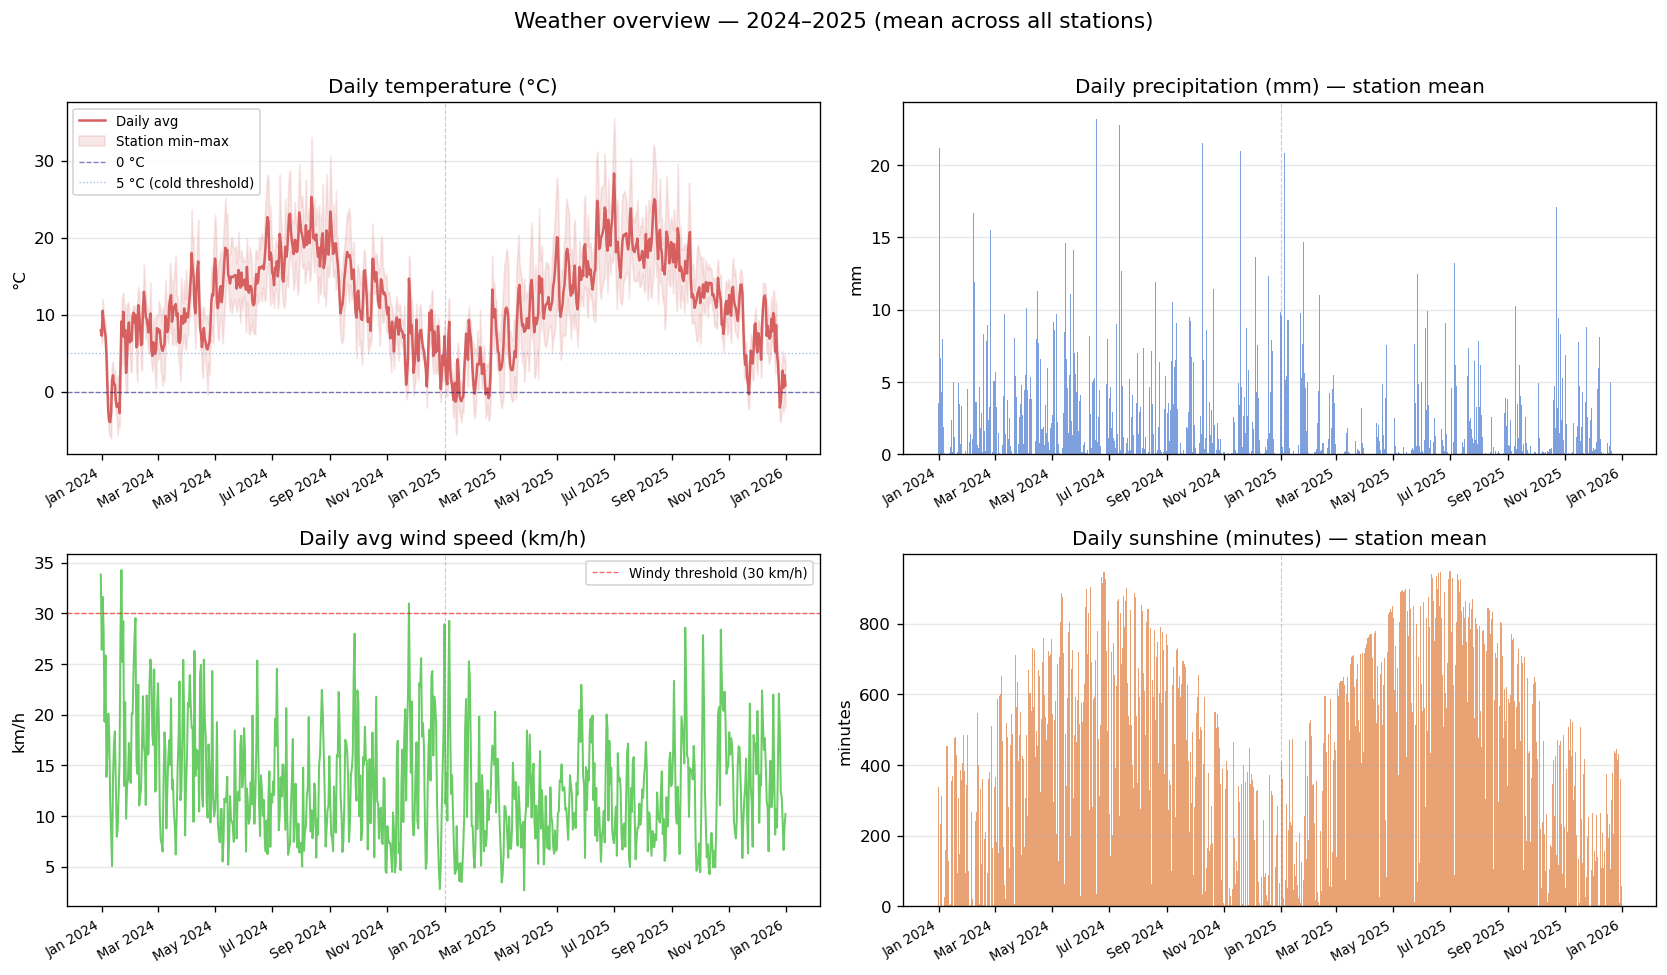

fig06_weather_overview.png saved.


In [9]:
# ── cross-station daily means for overview ────────────────────────────────────
wx_cross = (
    daily_weather.groupby("date", as_index=False).agg(
        temp_avg    =("temp_avg",     "mean"),
        temp_max    =("temp_max",     "mean"),
        temp_min    =("temp_min",     "mean"),
        precip_total=("precip_total", "mean"),
        wind_avg    =("wind_avg",     "mean"),
        sunshine_min=("sunshine_min", "mean"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# temperature
ax = axes[0, 0]
ax.plot(wx_cross["date"], wx_cross["temp_avg"],
        color="#d65f5f", lw=1.5, label="Daily avg")
ax.fill_between(wx_cross["date"], wx_cross["temp_min"], wx_cross["temp_max"],
                color="#d65f5f", alpha=0.15, label="Station min–max")
ax.axhline(0, color="navy",   lw=0.8, ls="--", alpha=0.5, label="0 °C")
ax.axhline(5, color="#4878d0", lw=0.8, ls=":",  alpha=0.5, label="5 °C (cold threshold)")
ax.set_title("Daily temperature (°C)")
ax.set_ylabel("°C")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# precipitation
ax = axes[0, 1]
ax.bar(wx_cross["date"], wx_cross["precip_total"],
       width=1, color="#4878d0", alpha=0.7)
ax.set_title("Daily precipitation (mm) — station mean")
ax.set_ylabel("mm")
ax.grid(axis="y", alpha=0.3)

# wind speed
ax = axes[1, 0]
ax.plot(wx_cross["date"], wx_cross["wind_avg"],
        color="#6acc65", lw=1.2)
ax.axhline(30, color="red", lw=0.8, ls="--", alpha=0.6, label="Windy threshold (30 km/h)")
ax.set_title("Daily avg wind speed (km/h)")
ax.set_ylabel("km/h")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# sunshine
ax = axes[1, 1]
ax.bar(wx_cross["date"], wx_cross["sunshine_min"],
       width=1, color="#e07b39", alpha=0.7)
ax.set_title("Daily sunshine (minutes) — station mean")
ax.set_ylabel("minutes")
ax.grid(axis="y", alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.axvline(pd.Timestamp("2025-01-01"), color="grey", lw=0.7, ls="--", alpha=0.4)

fig.suptitle("Weather overview — 2024–2025 (mean across all stations)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGS / "fig06_weather_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("fig06_weather_overview.png saved.")

Rainy hours (>0.1 mm): 476,483  (18.2% of all hours)


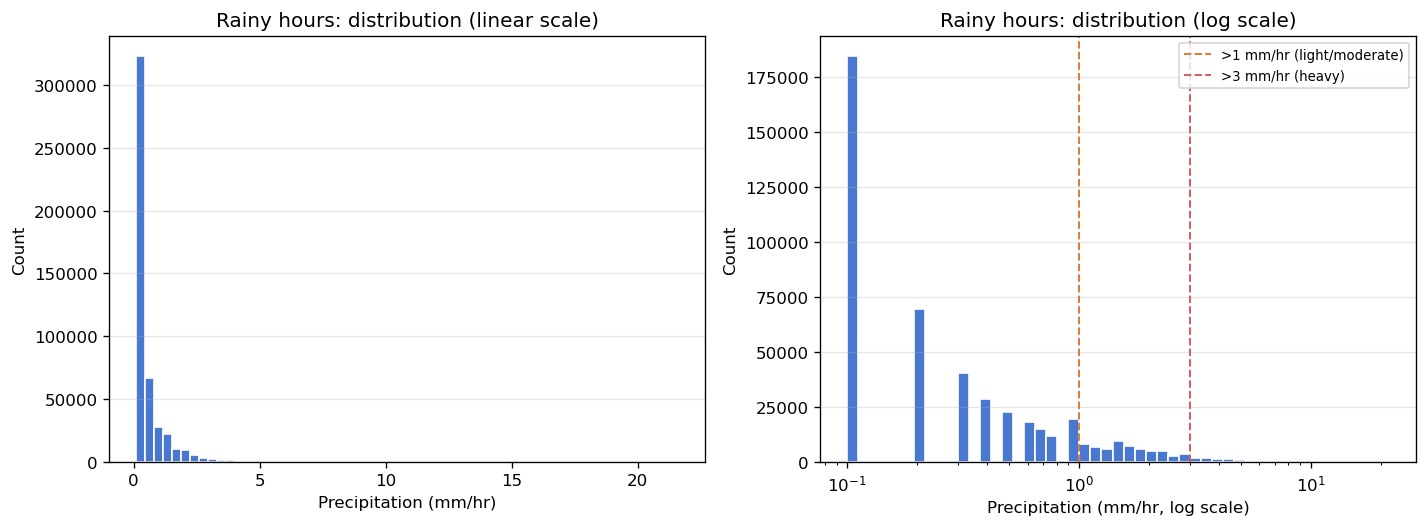

fig07_rain_distribution.png saved.


In [10]:
# ── rain distribution ─────────────────────────────────────────────────────────
rainy = weather_raw.loc[weather_raw["precipitation"] > 0.1, "precipitation"]
print(f"Rainy hours (>0.1 mm): {len(rainy):,}  ({len(rainy)/len(weather_raw)*100:.1f}% of all hours)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# linear
axes[0].hist(rainy, bins=60, color="#4878d0", edgecolor="white", lw=0.3)
axes[0].set_xlabel("Precipitation (mm/hr)")
axes[0].set_ylabel("Count")
axes[0].set_title("Rainy hours: distribution (linear scale)")
axes[0].grid(axis="y", alpha=0.3)

# log x-axis
log_bins = np.logspace(np.log10(0.1), np.log10(float(rainy.max()) + 0.1), 50)
axes[1].hist(rainy, bins=log_bins, color="#4878d0", edgecolor="white", lw=0.3)
axes[1].set_xscale("log")
axes[1].set_xlabel("Precipitation (mm/hr, log scale)")
axes[1].set_ylabel("Count")
axes[1].set_title("Rainy hours: distribution (log scale)")
for thresh, label, col in [(1.0, "light/moderate", "#e07b39"),
                            (3.0, "heavy",          "#d65f5f")]:
    axes[1].axvline(thresh, color=col, lw=1.2, ls="--",
                    label=f">{thresh:.0f} mm/hr ({label})")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIGS / "fig07_rain_distribution.png", dpi=150)
plt.show()
print("fig07_rain_distribution.png saved.")

## 9. Final Summary

In [11]:
pct_bad  = daily_weather["is_bad_weather"].mean() * 100
pct_rain = daily_weather["is_rainy_day"].mean()   * 100
pct_cold = daily_weather["is_cold_day"].mean()    * 100
pct_wind = daily_weather["is_windy_day"].mean()   * 100

daily_weather["season"] = daily_weather["date"].dt.month.map(SEASON_MAP)
season_temp = (
    daily_weather.groupby("season")["temp_avg"]
    .mean()
    .sort_values(ascending=False)
    .round(1)
)

print("=" * 52)
print("WEATHER DATA SUMMARY")
print("=" * 52)
print(f"weather_hourly : {weather_raw.shape[0]:>10,} rows × {weather_raw.shape[1]} cols")
print(f"weather_daily  : {daily_weather.shape[0]:>10,} rows × {daily_weather.shape[1]} cols")
print(f"Date range     : {daily_weather['date'].min().date()} → {daily_weather['date'].max().date()}")
print(f"Stations       : {daily_weather['site ID'].nunique()}")
print()
print(f"Bad weather station-days (any flag) : {pct_bad:.1f}%")
print(f"  of which  rainy (>1 mm)           : {pct_rain:.1f}%")
print(f"            cold  (<5 °C)           : {pct_cold:.1f}%")
print(f"            windy (>30 km/h)        : {pct_wind:.1f}%")
print()
print("Average temperature by season:")
for s, t in season_temp.items():
    print(f"  {s:<8} : {t:>5.1f} °C")
print()
sz_h = (PROCESSED / "weather_hourly.parquet").stat().st_size / 1_048_576
sz_d = (PROCESSED / "weather_daily.parquet").stat().st_size  / 1_048_576
print(f"weather_hourly.parquet : {sz_h:.1f} MB")
print(f"weather_daily.parquet  : {sz_d:.1f} MB")
print()
print("Both parquet files saved successfully.")

WEATHER DATA SUMMARY
weather_hourly :  2,614,056 rows × 20 cols
weather_daily  :    109,068 rows × 20 cols
Date range     : 2023-12-31 → 2025-12-31
Stations       : 149

Bad weather station-days (any flag) : 50.0%
  of which  rainy (>1 mm)           : 38.3%
            cold  (<5 °C)           : 14.8%
            windy (>30 km/h)        : 0.8%

Average temperature by season:
  summer   :  18.5 °C
  autumn   :  11.9 °C
  spring   :  11.3 °C
  winter   :   5.0 °C

weather_hourly.parquet : 29.3 MB
weather_daily.parquet  : 2.6 MB

Both parquet files saved successfully.


The date range starts on 2023-12-31, so there is one extra day. This happens because when Open-Meteo’s UTC timestamps are converted to Brussels time (UTC+1), 2024-01-01 00:00 in Brussels corresponds to 2023-12-31 23:00 UTC, which introduces one additional row.
This does not affect the analysis, because that extra row is naturally filtered out when joining with panel_daily.